
## Application: Home Mortgage Disclosure Act Data
---

### Dependent variable

+ deny - Was the mortgage denied?

### Independent variables

+ pirat - Payments to income ratio.
+ hirat - Housing expense to income ratio.
+ lvrat - Loan to value ratio.
+ chist - Credit history: consumer payments.
+ mhist - Credit history: mortgage payments.
+ phist - Public bad credit record?
+ unemp - 1989 Massachusetts unemployment rate in applicant's industry.
+ selfemp - Is the individual self-employed?
+ insurance - Was the individual denied mortgage insurance?
+ condomin - Is the unit a condominium?
+ afam - Is the individual African-American?
+ single - Is the individual single?
+ hschool - Does the individual have a high-school diploma?

### Source

Online complements to Stock and Watson (2007).

### References

+ Munnell, A. H., Tootell, G. M. B., Browne, L. E. and McEneaney, J. (1996). Mortgage Lending in Boston: Interpreting HMDA Data. American Economic Review, 86, 25–53.
+ Stock, J. H. and Watson, M. W. (2007). Introduction to Econometrics, 2nd ed. Boston: Addison Wesley.

https://vincentarelbundock.github.io/Rdatasets/datasets.html


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
from arviz_base import dict_to_dataset
from arviz_plots import plot_autocorr, plot_dist, plot_trace_dist
from arviz_stats import summary
from IPython.display import display

In [2]:
hmda = pd.read_csv('HMDA.csv', index_col=0)
display(hmda)

,deny,pirat,hirat,lvrat,chist,mhist,phist,unemp,selfemp,insurance,condomin,afam,single,hschool
1,no,0.221,0.221,0.800000,5,2,no,3.9,no,no,no,no,no,yes
2,no,0.265,0.265,0.921875,2,2,no,3.2,no,no,no,no,yes,yes
3,no,0.372,0.248,0.920398,1,2,no,3.2,no,no,no,no,no,yes
4,no,0.320,0.250,0.860465,1,2,no,4.3,no,no,no,no,no,yes
5,no,0.360,0.350,0.600000,1,1,no,3.2,no,no,no,no,no,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2376,no,0.310,0.250,0.800000,1,1,no,3.2,yes,no,no,no,no,yes
2377,no,0.300,0.300,0.777049,1,2,no,3.2,no,no,yes,no,yes,yes
2378,no,0.260,0.200,0.526761,2,1,no,3.1,no,no,no,no,no,yes
2379,yes,0.320,0.260,0.753846,6,1,yes,3.1,no,no,yes,yes,yes,yes


In [3]:
dummy_variables = ['deny', 'phist', 'selfemp', 'insurance', 'condomin', 'afam', 'single', 'hschool']
hmda[dummy_variables] = hmda[dummy_variables].replace({'yes':1, 'no':0})
display(hmda)

,deny,pirat,hirat,lvrat,chist,mhist,phist,unemp,selfemp,insurance,condomin,afam,single,hschool
1,0,0.221,0.221,0.800000,5,2,0,3.9,0,0,0,0,0,1
2,0,0.265,0.265,0.921875,2,2,0,3.2,0,0,0,0,1,1
3,0,0.372,0.248,0.920398,1,2,0,3.2,0,0,0,0,0,1
4,0,0.320,0.250,0.860465,1,2,0,4.3,0,0,0,0,0,1
5,0,0.360,0.350,0.600000,1,1,0,3.2,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2376,0,0.310,0.250,0.800000,1,1,0,3.2,1,0,0,0,0,1
2377,0,0.300,0.300,0.777049,1,2,0,3.2,0,0,1,0,1,1
2378,0,0.260,0.200,0.526761,2,1,0,3.1,0,0,0,0,0,1
2379,1,0.320,0.260,0.753846,6,1,1,3.1,0,0,1,1,1,1


In [4]:
deny = hmda['deny'].to_numpy(dtype='float64')
features = hmda[hmda.columns[1:]].to_numpy(dtype='float64')
y = deny
X = np.hstack((np.ones((len(deny), 1)), features))
var_names = ['constant', 'pirat', 'hirat', 'lvrat', 'chist', 'mhist', 'phist', 'unemp', 'selfemp', 'insurance', 'condomin', 'afam', 'single', 'hschool']

### Logit model of mortgage denial

\begin{align*}
  \log\frac{p_{i}}{1 - p_{i}} &= \text{constant}
   + \beta_{1}\ \text{pirat}
   + \beta_{2}\ \text{hirat}
   + \beta_{3}\ \text{lvrat}
   + \beta_{4}\ \text{chist}
   + \beta_{5}\ \text{mhist} \\
   &\quad + \beta_{6}\ \text{phist}
   + \beta_{7}\ \text{unemp}
   + \beta_{8}\ \text{selfemp}
   + \beta_{9}\ \text{insurance} \\
   &\quad + \beta_{10}\ \text{condomin}
   + \beta_{11}\ \text{afam}
   + \beta_{12}\ \text{single}
   + \beta_{13}\ \text{hschool},
\end{align*}

where

$$
  p_{i} = \Pr\{\text{Person $i$'s mortgage application is denied.}\}.
$$


In [5]:
k = X.shape[1]
b0, A0 = np.zeros(k), 0.01 * np.eye(k)
logit_model = pm.Model()
with logit_model:
    y_data = pm.Data('y_data', y)
    X_data = pm.Data('X_data', X)
    b = pm.MvNormal('b', mu=b0, tau=A0, shape=k)
    idx = X_data @ b
    likelihood = pm.Bernoulli('y', p=pm.math.invlogit(idx), observed=y_data)
n_draws, n_chains, n_tune = 5000, 4, 1000
with logit_model:
    trace_logit = pm.sample(draws=n_draws, chains=n_chains, tune=n_tune, target_accept=0.9, random_seed=123)
results_logit = summary(trace_logit, ci_prob=0.95)
results_logit.index = var_names
sim_param_logit = dict_to_dataset(dict([(var, trace_logit.posterior['b'].to_numpy()[:, :, index]) for index, var in enumerate(var_names)]))

NUTS[nutpie]: [b]


Output()

In [6]:
display(results_logit)

,mean,sd,eti95_lb,eti95_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
constant,-6.097294,0.699643,-7.476901,-4.731614,4844.509192,6993.716421,1.001212,0.010053,0.005674
pirat,4.789364,1.047954,2.750627,6.861091,8489.580194,10581.96945,1.000385,0.011374,0.007252
hirat,-0.402229,1.242816,-2.839274,2.033463,9182.293236,11428.847578,1.00009,0.012971,0.008578
lvrat,1.814658,0.505637,0.821981,2.802945,9112.229714,11073.571702,1.000176,0.005295,0.003374
chist,0.298696,0.039883,0.220623,0.375624,27328.25339,15665.449309,1.000287,0.000241,0.000298
mhist,0.241018,0.144078,-0.043087,0.522677,14767.858607,13775.070001,1.000046,0.001186,0.000971
phist,1.243293,0.204979,0.838375,1.646652,34641.028364,15923.209867,1.000391,0.001102,0.001523
unemp,0.058688,0.034155,-0.009225,0.124608,24284.485516,14981.089629,1.000119,0.000219,0.000244
selfemp,0.645983,0.213494,0.220392,1.059057,34434.196821,15613.077608,1.000206,0.001153,0.001622
insurance,4.673353,0.574596,3.64621,5.912865,33422.737394,13906.768822,1.000155,0.003282,0.004761


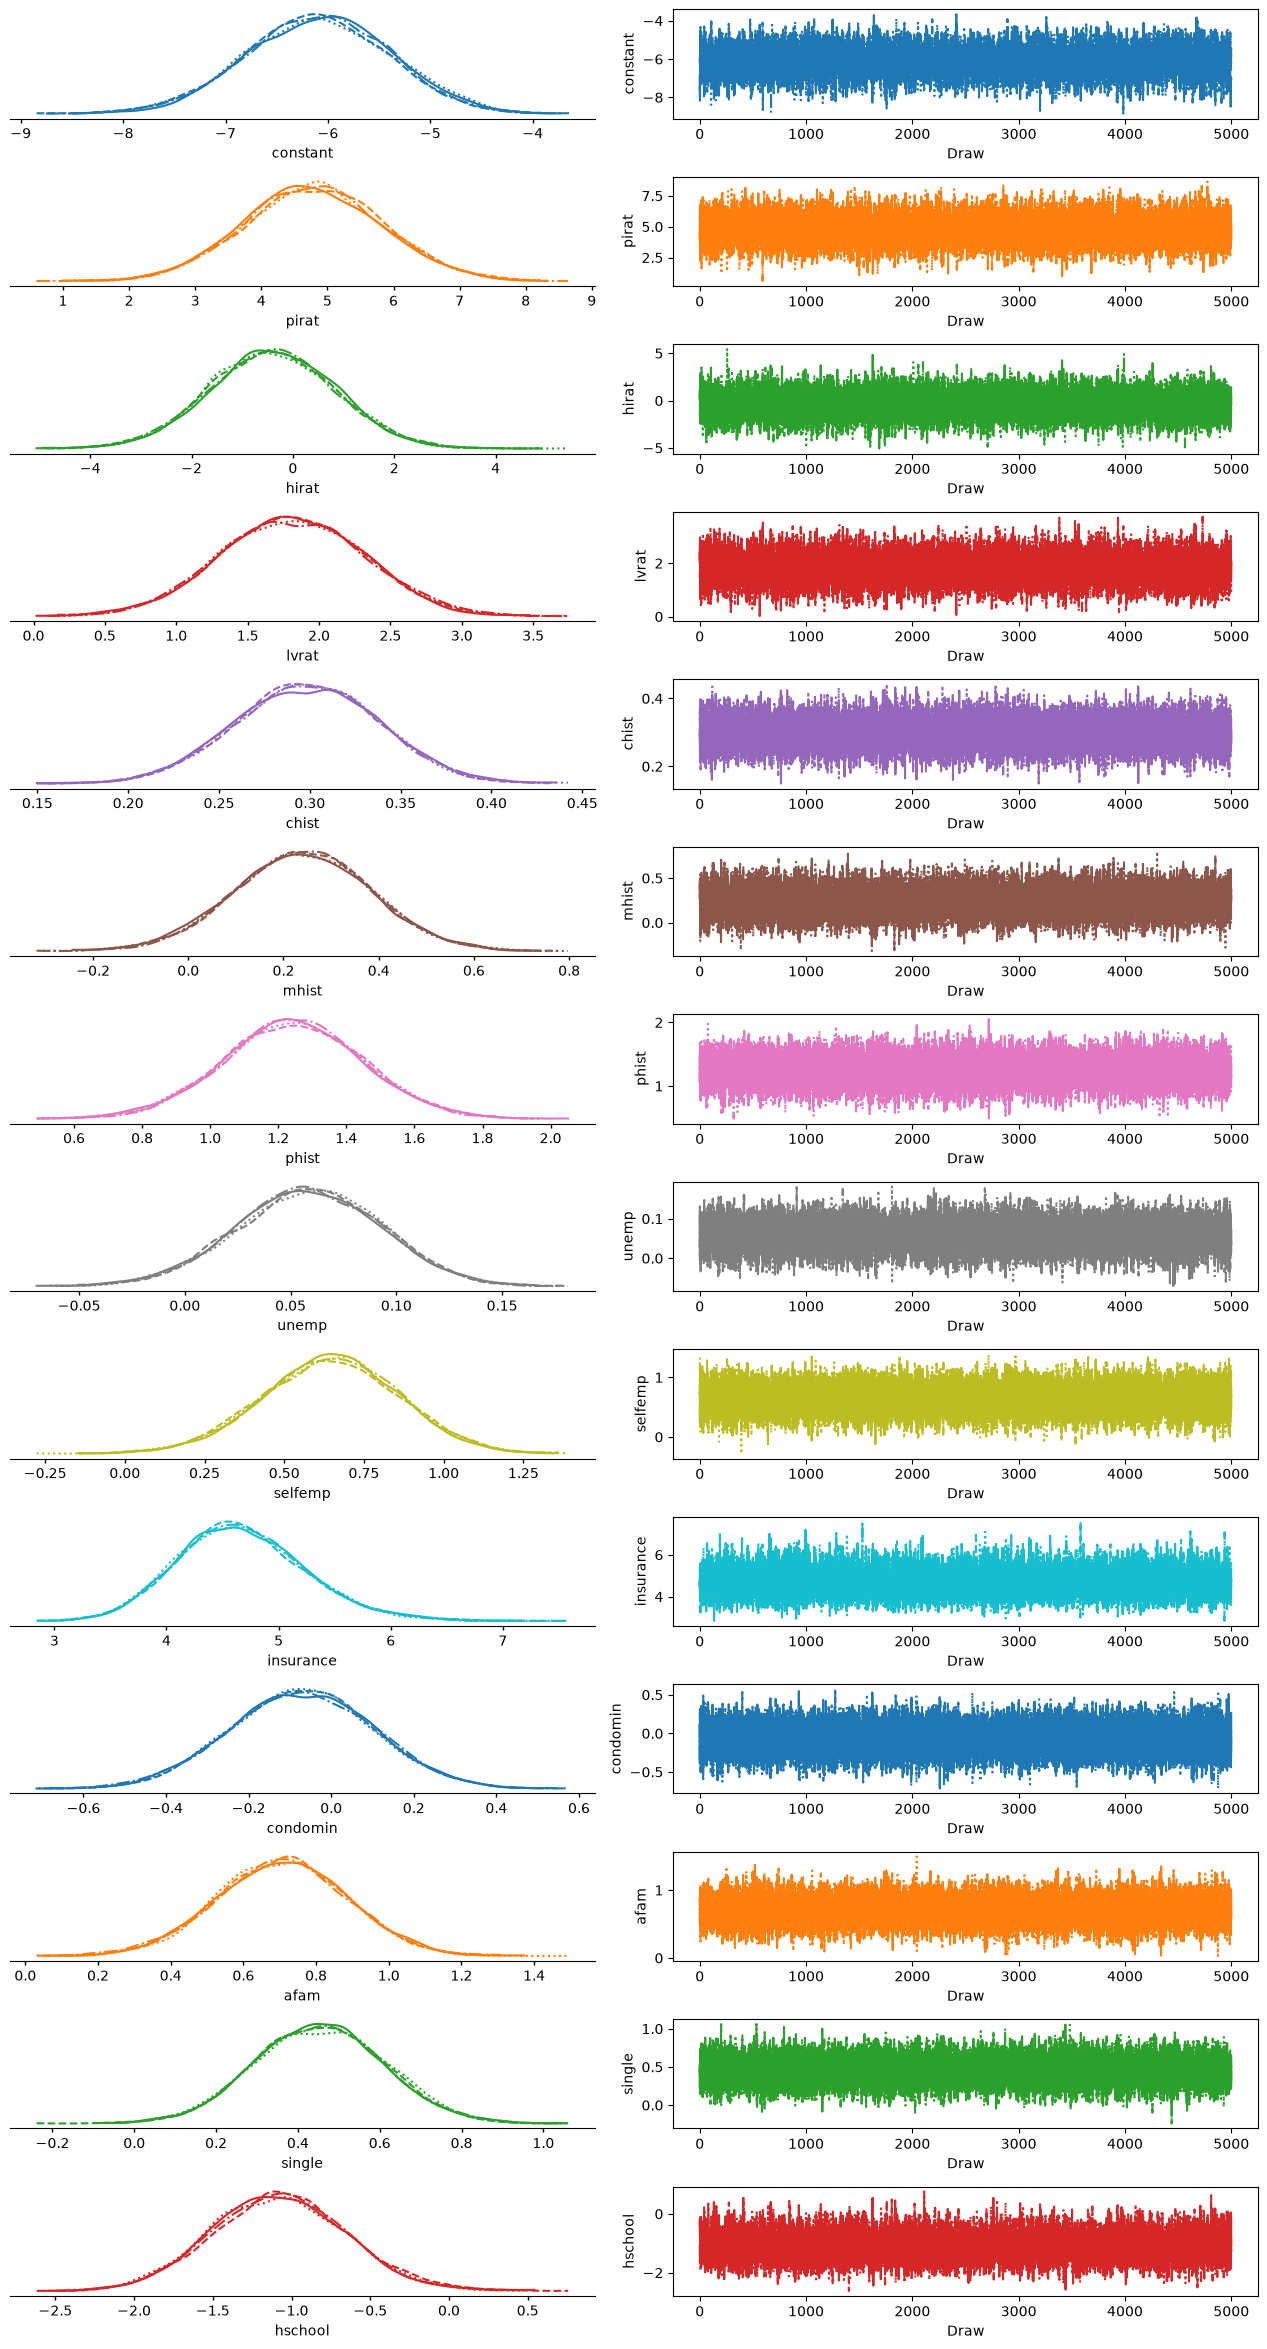

In [7]:
plot_trace_dist(sim_param_logit)
plt.tight_layout()
plt.show()

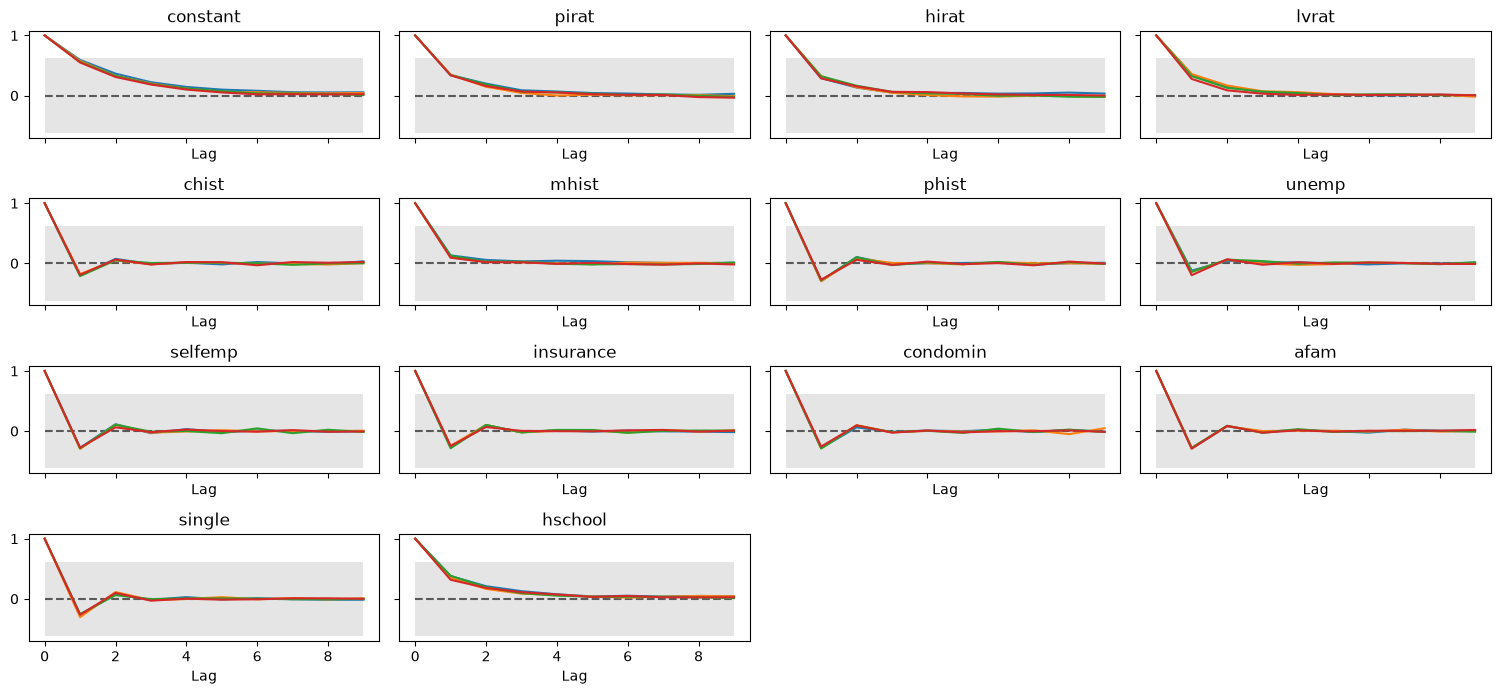

In [8]:
plot_autocorr(sim_param_logit, max_lag=10)
plt.tight_layout()
plt.show()

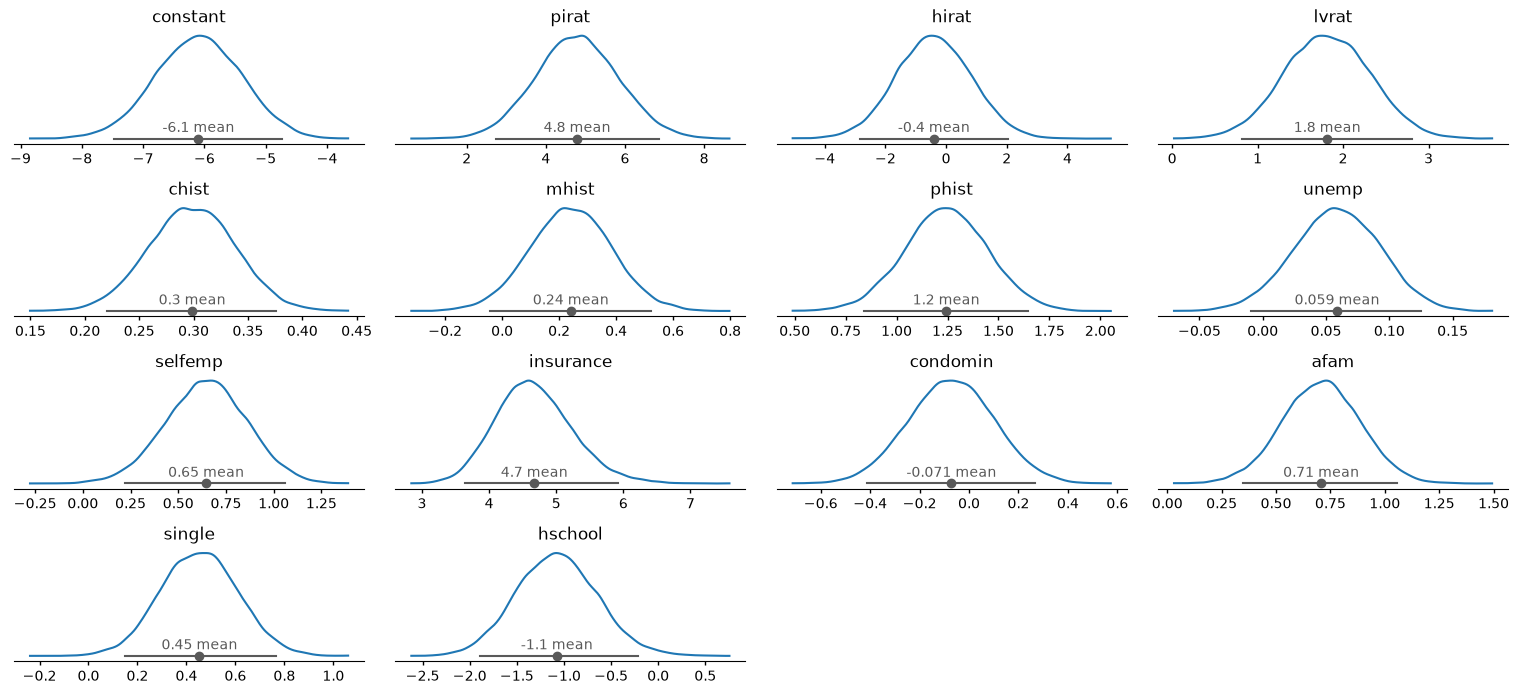

In [9]:
plot_dist(sim_param_logit, kind='kde', point_estimate='mean', ci_prob=0.95)
plt.tight_layout()
plt.show()

### Probit model of mortgage denial

\begin{align*}
  p_{i} &= \Pr\{\text{Person $i$'s mortgage application is denied.}\} \\
  &= \Pr\{Z \leqq I_{i}\} = \int_{-\infty}^{I_{i}}\frac{1}{\sqrt{2\pi}}\exp\left(-\frac{z^{2}}{2}\right)dz, \\
  I_{i} &= \text{constant}
   + \beta_{1}\ \text{pirat}
   + \beta_{2}\ \text{hirat}
   + \beta_{3}\ \text{lvrat}
   + \beta_{4}\ \text{chist}
   + \beta_{5}\ \text{mhist} \\
   &\quad + \beta_{6}\ \text{phist}
   + \beta_{7}\ \text{unemp}
   + \beta_{8}\ \text{selfemp}
   + \beta_{9}\ \text{insurance} \\
   &\quad + \beta_{10}\ \text{condomin}
   + \beta_{11}\ \text{afam}
   + \beta_{12}\ \text{single}
   + \beta_{13}\ \text{hschool}.
\end{align*}


In [10]:
probit_model = pm.Model()
with probit_model:
    y_data = pm.Data('y_data', y)
    X_data = pm.Data('X_data', X)
    b = pm.MvNormal('b', mu=b0, tau=A0, shape=k)
    idx = X_data @ b
    likelihood = pm.Bernoulli('y', p=pm.math.invprobit(idx), observed=y_data)
n_draws, n_chains, n_tune = 5000, 4, 1000
with probit_model:
    trace_probit = pm.sample(draws=n_draws, chains=n_chains, tune=n_tune, target_accept=0.9, random_seed=123)
results_probit = summary(trace_probit, ci_prob=0.95)
results_probit.index = var_names
sim_param_probit = dict_to_dataset(dict([(var, trace_probit.posterior['b'].to_numpy()[:, :, index]) for index, var in enumerate(var_names)]))

NUTS[nutpie]: [b]


Output()

In [11]:
display(results_probit)

,mean,sd,eti95_lb,eti95_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
constant,-3.127867,0.36717,-3.850849,-2.418866,4950.234262,7330.057533,1.000237,0.00522,0.00303
pirat,2.497877,0.533911,1.448104,3.555132,8800.904068,11132.775163,1.000233,0.005687,0.003682
hirat,-0.346954,0.659331,-1.643671,0.944103,9233.425727,11586.743917,1.000202,0.006861,0.004488
lvrat,0.797877,0.245423,0.321529,1.285227,9932.559881,11922.024141,1.000095,0.002464,0.00176
chist,0.158542,0.021449,0.11658,0.200515,27825.944769,15765.20641,1.000068,0.000129,0.00016
mhist,0.121765,0.074883,-0.024976,0.266556,15418.891932,14357.848272,1.000434,0.000603,0.000531
phist,0.709994,0.117475,0.480601,0.937779,31043.80231,17641.29231,1.000201,0.000667,0.000803
unemp,0.031312,0.018087,-0.004179,0.06641,23739.375229,15040.638204,1.000101,0.000117,0.000135
selfemp,0.340151,0.112498,0.116775,0.557958,30669.528156,15467.624042,1.00013,0.000643,0.000833
insurance,2.601691,0.290956,2.054594,3.194149,32771.70078,13654.435154,0.999872,0.001633,0.002398


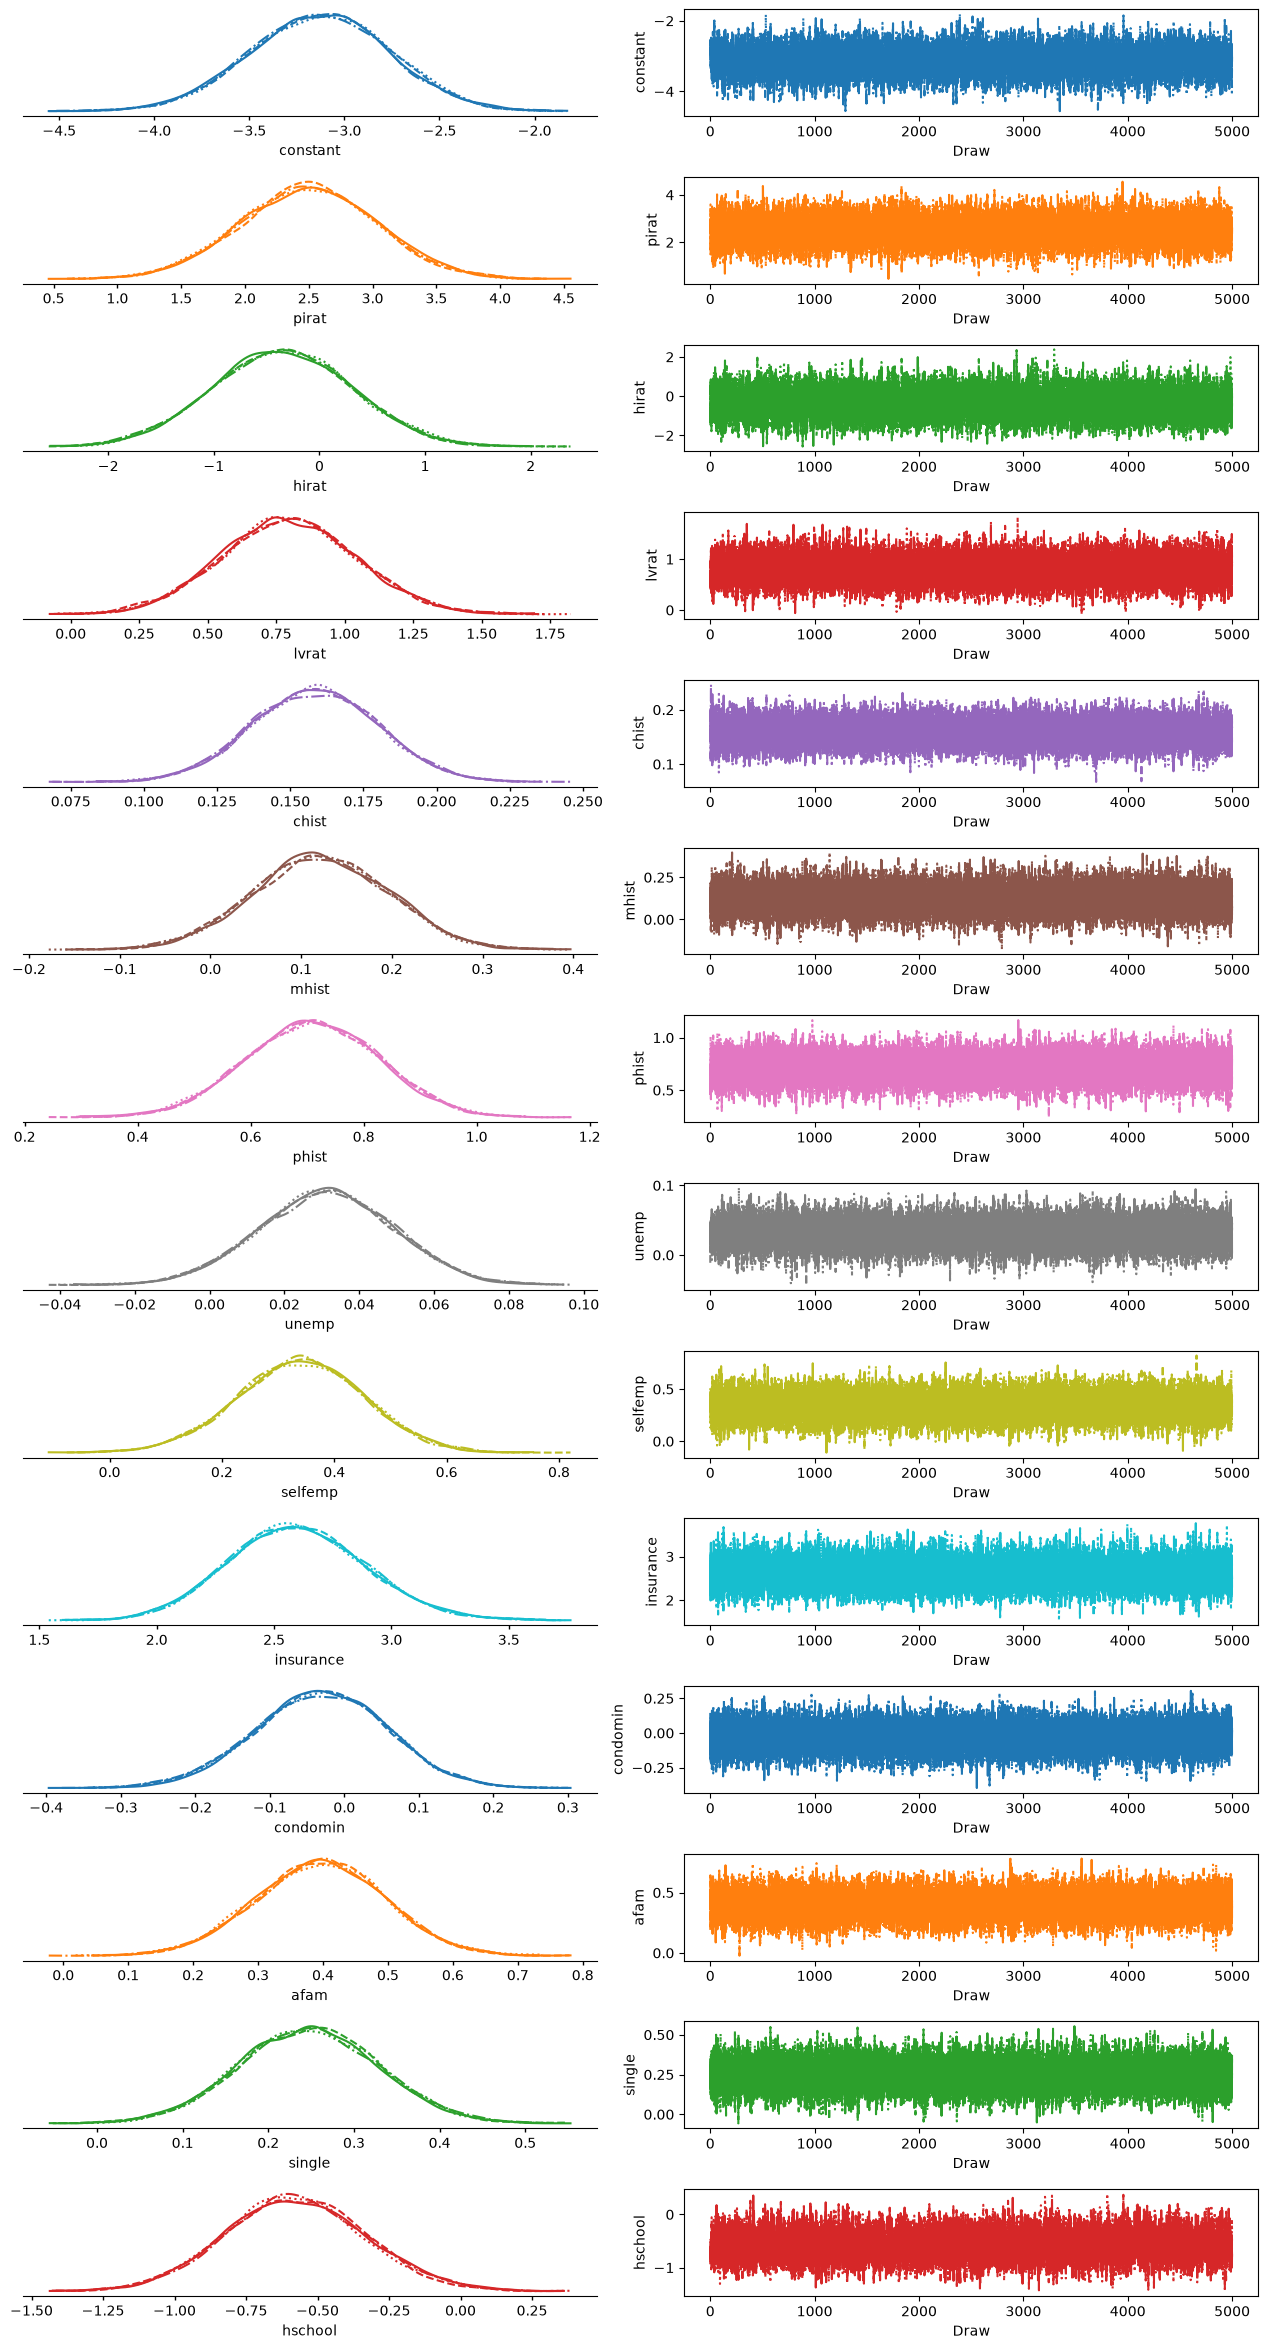

In [12]:
plot_trace_dist(sim_param_probit)
plt.tight_layout()
plt.show()

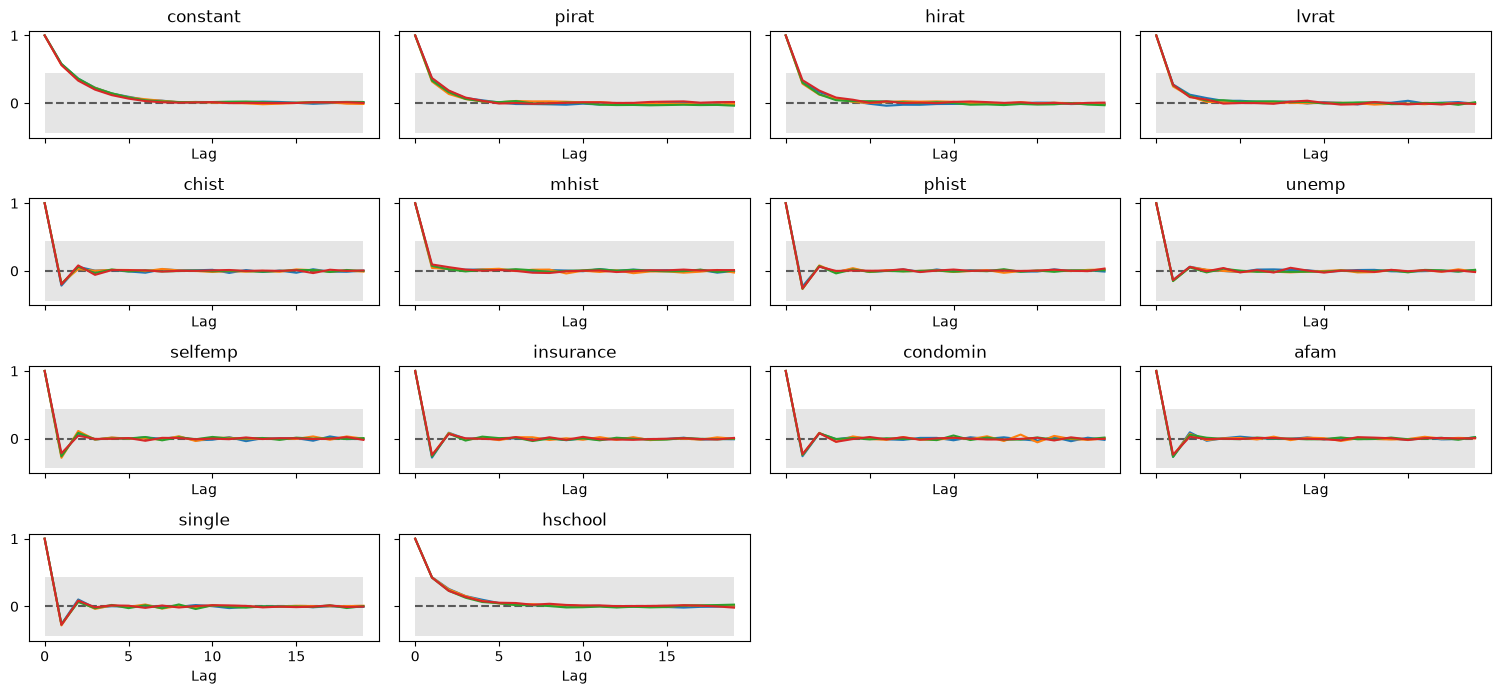

In [13]:
plot_autocorr(sim_param_probit, max_lag=20)
plt.tight_layout()
plt.show()

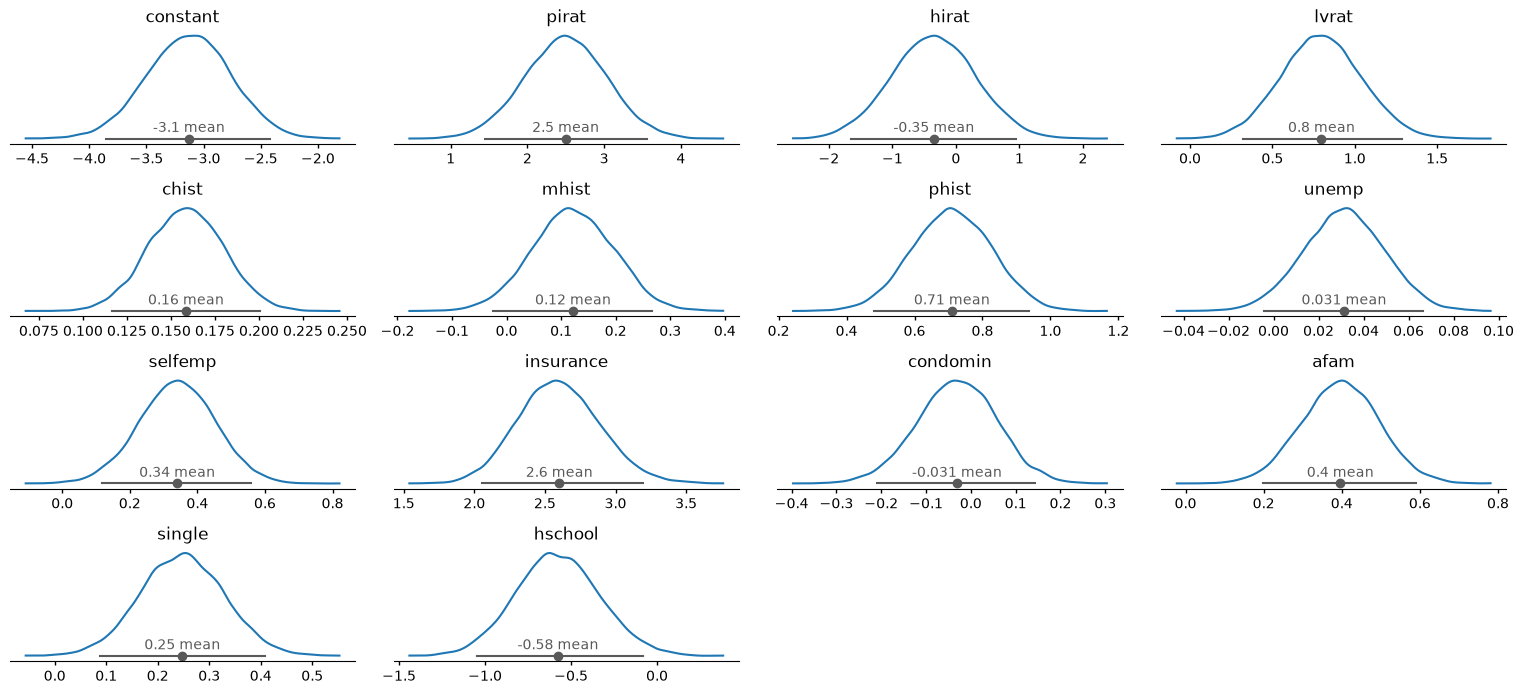

In [14]:
plot_dist(sim_param_probit, kind='kde', point_estimate='mean', ci_prob=0.95)
plt.tight_layout()
plt.show()